### Importing Libraries

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

GPU Usage?

In [2]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU!")

    gpus = tf.config.list_physical_devices('GPU')
    print("Available GPUs:", gpus)

    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("TensorFlow is using the CPU.")

TensorFlow is using the GPU!
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU', 'compute_capability': (8, 6)}


In [3]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = r"C:\CODES__SSD512\minorP_Pneumonia\Notebooks\H5\E3_BaselineCNN_P1I1A3M1T1.h5"


if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("\nModel loaded successfully")
else:
    print("\nModel not found! Check the path.")


Model not found! Check the path.


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Pneumonia Data___Set


In [5]:
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):
    data = []
    for label in labels:
        path = os.path.join(dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                if img.endswith('jpeg'):
                    img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data,dtype= 'object')


In [6]:
train = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\train")
val   = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\val")
test  = get_data(r"C:\CODES__SSD512\minorP_Pneumonia\ChestXRay2017\chest_xray\test")

In [7]:
def count_images(dataset, name):

    pneumonia = 0
    normal = 0

    for i in dataset:
        if i[1] == 0:
            pneumonia += 1
        else:
            normal += 1

    total = pneumonia + normal

    print(f"\n{name} DATASET:")
    print("Total images:", total)
    print("PNEUMONIA images:", pneumonia)
    print("NORMAL images:", normal)


count_images(train, "TRAIN")
count_images(val, "VALIDATION")
count_images(test, "TEST")


TRAIN DATASET:
Total images: 5170
PNEUMONIA images: 3852
NORMAL images: 1318

VALIDATION DATASET:
Total images: 62
PNEUMONIA images: 31
NORMAL images: 31

TEST DATASET:
Total images: 624
PNEUMONIA images: 390
NORMAL images: 234


## Data Visualization && Preprocessing

<Axes: xlabel='count'>

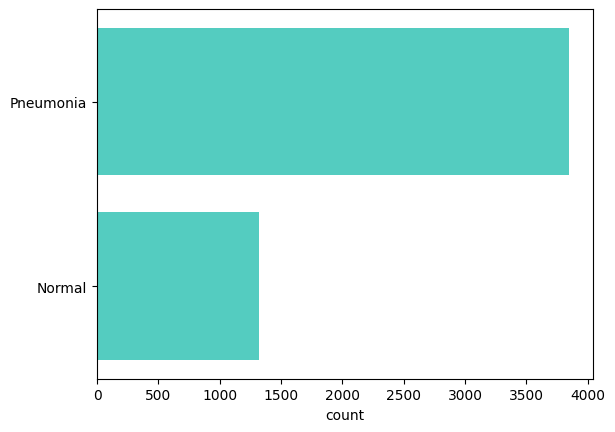

In [8]:
l = []
for i in train:
    if (i[1] == 0):
        l.append('Pneumonia')
    else:
        l.append('Normal')

sns.countplot(y=l, color='#40E0D0')

Text(0.5, 1.0, 'NORMAL')

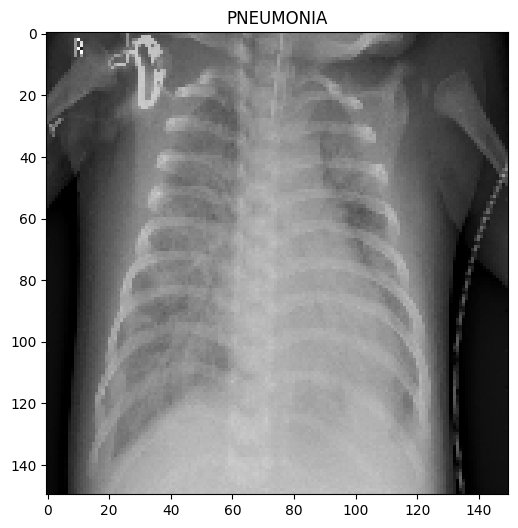

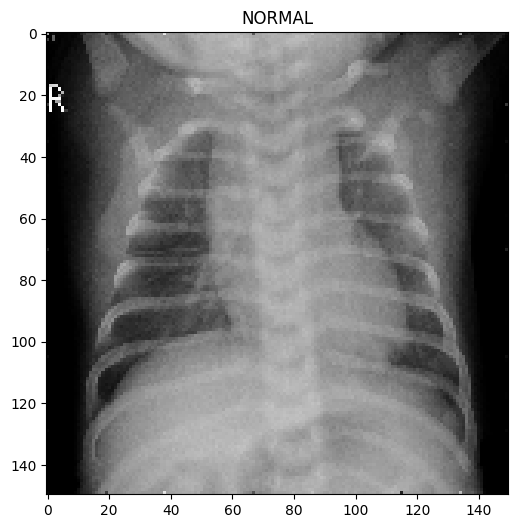

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [10]:
x_train = []
y_train = []
for feat, label in train:
    x_train.append(feat)
    y_train.append(label)


x_val = []
y_val = []
for feat,label in val:
    x_val.append(feat)
    y_val.append(label)


x_test = []
y_test = []
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)


## Normalizing       data ........

In [11]:
#Normalizing.... data
# for reducing computation....
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

# suitable for CNN

In [12]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

# data augmentation

In [13]:
data__gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

data__gen.fit(x_train)

## Train........

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential()


# First Convolution Layer
model.add(Conv2D(
    32,
    (3, 3),
    activation='relu',
    input_shape=(150, 150, 1)
))

model.add(MaxPool2D(
    (2, 2)
))


# Second Convolution Layer
model.add(Conv2D(
    64,
    (3, 3),
    activation='relu'
))

model.add(MaxPool2D(
    (2, 2)
))


# Third Convolution Layer
model.add(Conv2D(
    128,
    (3, 3),
    activation='relu'
))

model.add(MaxPool2D(
    (2, 2)
))


# Flatten Layer
model.add(Flatten())


# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))


# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))


# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [15]:
# learning_rate_reduction = ReduceLROnPlateau(
#     monitor='val_accuracy',
#     patience=2,
#     verbose=1,
#     factor=0.3,
#     min_lr=0.000001
# )


# T1 = Default training


In [16]:
# checkpoint = ModelCheckpoint(
#     MODEL_PATH,
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# No checkpoint

In [17]:
# from sklearn.utils.class_weight import compute_class_weight

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = dict(enumerate(class_weights))
# print(class_weights)

# T1 = Default training

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    data__gen.flow(x_train, y_train, batch_size=16),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
324/324 [==============================] - 12s 31ms/step - loss: 0.3664 - accuracy: 0.8420 - val_loss: 0.3363 - val_accuracy: 0.8710
Epoch 2/30
324/324 [==============================] - 9s 27ms/step - loss: 0.2478 - accuracy: 0.8963 - val_loss: 0.2191 - val_accuracy: 0.9032
Epoch 3/30
324/324 [==============================] - 8s 25ms/step - loss: 0.1934 - accuracy: 0.9226 - val_loss: 0.1627 - val_accuracy: 0.9194
Epoch 4/30
324/324 [==============================] - 8s 26ms/step - loss: 0.1703 - accuracy: 0.9335 - val_loss: 0.1191 - val_accuracy: 0.9516
Epoch 5/30
324/324 [==============================] - 8s 25ms/step - loss: 0.1691 - accuracy: 0.9354 - val_loss: 0.0981 - val_accuracy: 0.9677
Epoch 6/30
324/324 [==============================] - 8s 26ms/step - loss: 0.1551 - accuracy: 0.9412 - val_loss: 0.0950 - val_accuracy: 0.9677
Epoch 7/30
324/324 [==============================] - 9s 27ms/step - loss: 0.1390 - accuracy: 0.9470 - val_loss: 0.0691 - val_accuracy: 0.983

In [19]:
model.save(MODEL_PATH)
print("Model saved successfully in Drive")

Model saved successfully in Drive


In [20]:
model.evaluate(x_test,y_test)

20/20 [==============================] - 0s 11ms/step - loss: 0.6104 - accuracy: 0.8029


[0.6104352474212646, 0.8028846383094788]

In [21]:
loss, acc = model.evaluate(x_test, y_test, batch_size=4, verbose=1)

print(f"Loss of the model is {loss}")
print(f"Accuracy of the model is {acc*100:.2f} %")

156/156 [==============================] - 1s 5ms/step - loss: 0.6105 - accuracy: 0.8029
Loss of the model is 0.6104901432991028
Accuracy of the model is 80.29 %


# Analyse Model Performance

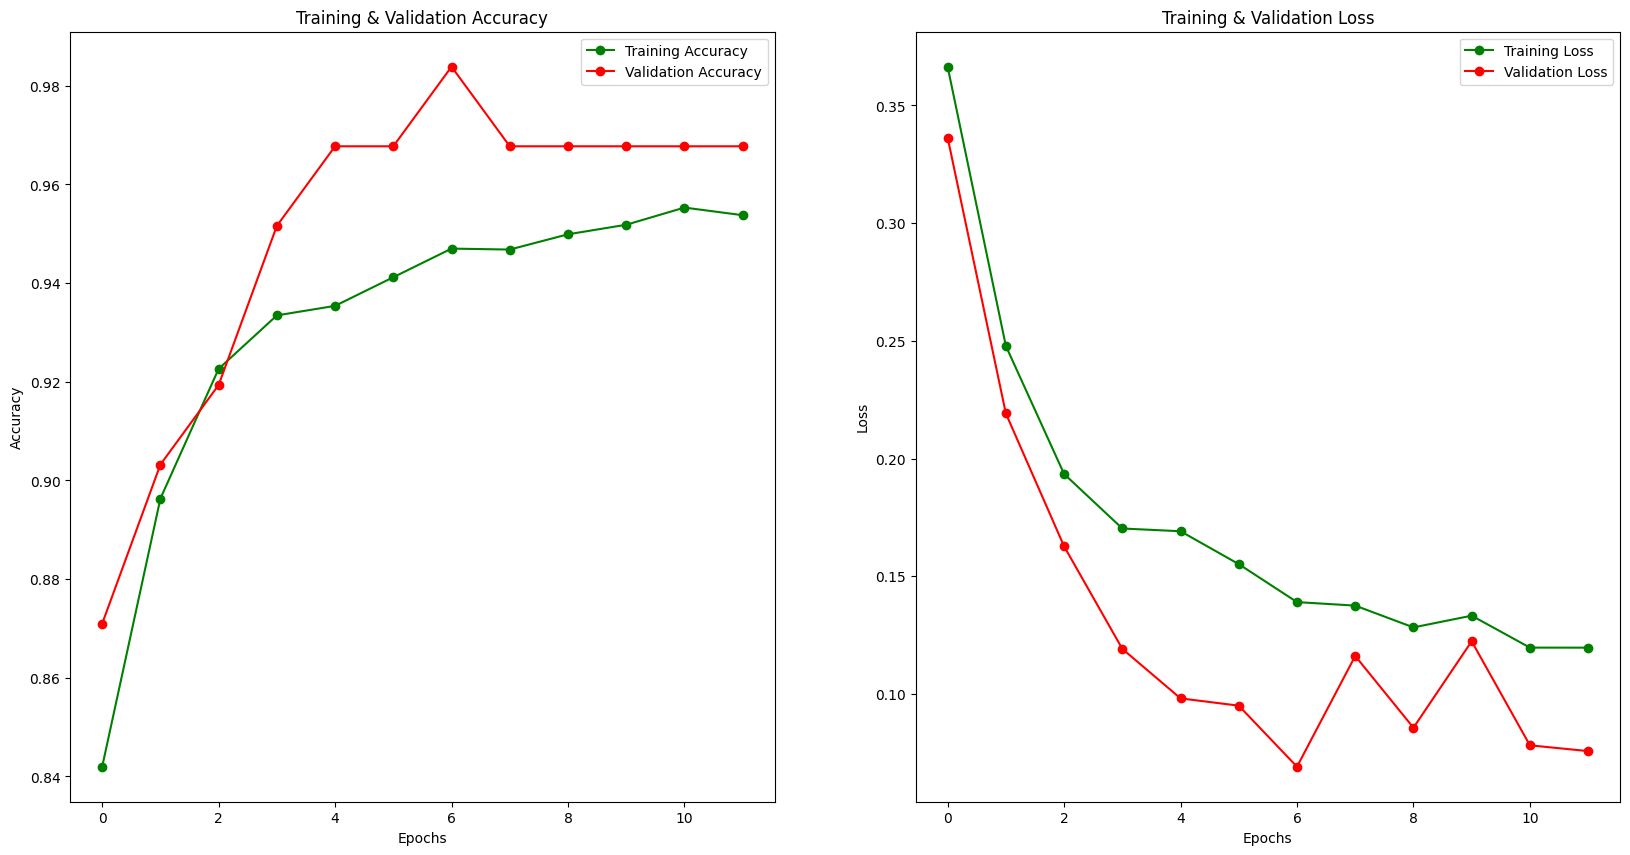

In [22]:
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [23]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 [==============================] - 0s 9ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))


                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.76      0.99      0.86       390
   Normal (Class 1)       0.97      0.49      0.65       234

           accuracy                           0.80       624
          macro avg       0.87      0.74      0.76       624
       weighted avg       0.84      0.80      0.78       624



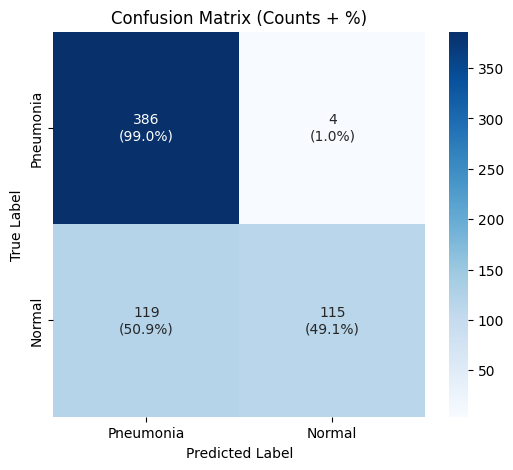

In [25]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]



import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

# Label
labels = ['Pneumonia', 'Normal']

#percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"


# Plottin confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Counts + %)")
plt.show()

#Some correctly Predicted Classes---->>>

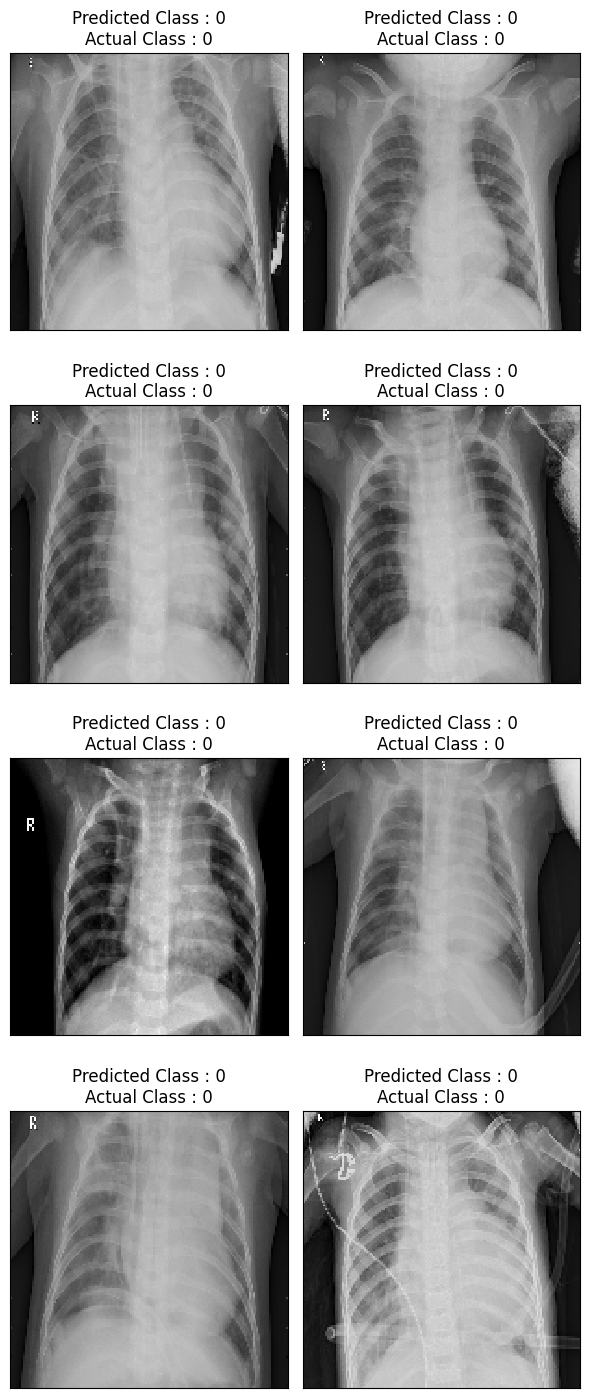

In [26]:

i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(img_resize,img_resize), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

#Some incorrectly Predicted Classes____>>>

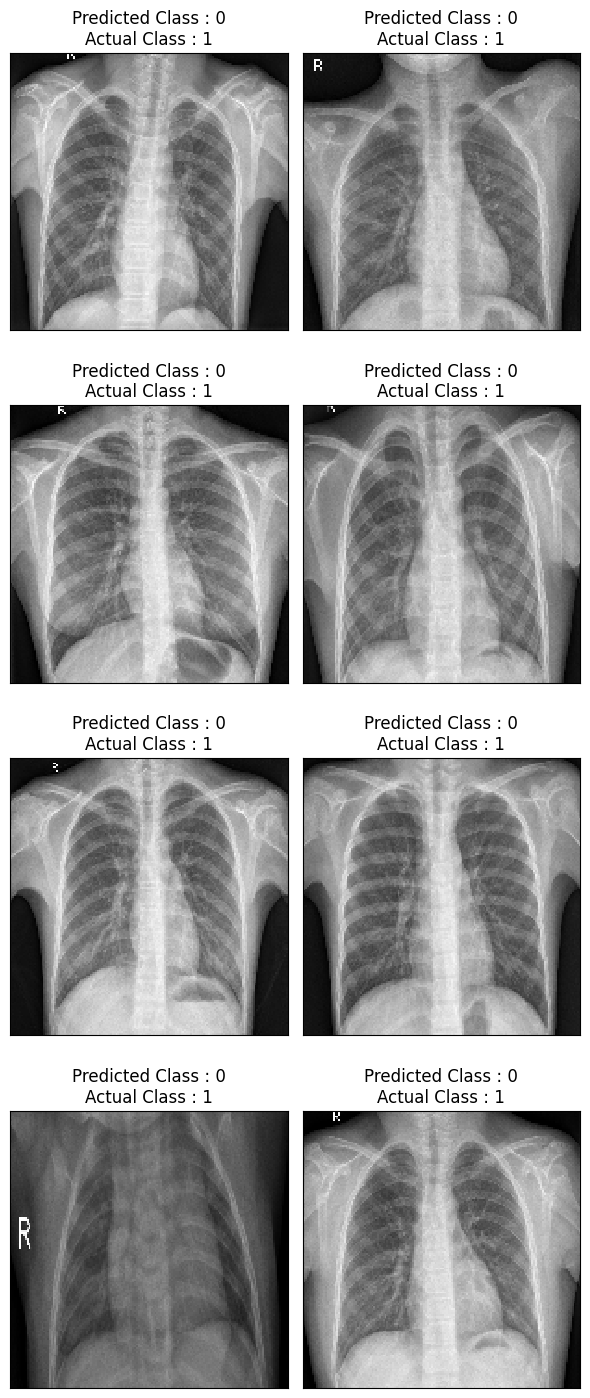

In [27]:
# //for incorrect predicted classes hum normal ko Penumonia dekha
# sakte hai but not vice versa........

i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(img_resize,img_resize), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1